**Mount Drive (Google Colab)**

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Dataset Loading and Inspection**

In [18]:
import pandas as pd

telco_data = pd.read_csv('drive/My Drive/Datasets For ML/Telco Customer Churn.csv')

print("Shape:", telco_data.shape)
print("\nDuplicated:", telco_data.duplicated().sum())
print("\nNull Values:", telco_data.isnull().sum().sum())
print("\nFirst 2 Rows:")
telco_data.head(2)

Shape: (7043, 21)

Duplicated: 0

Null Values: 0

First 2 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


**Data Preprocessing**

Remove CustomerID (Not Useful for Prediction)

In [19]:
telco_data = telco_data.drop('customerID', axis=1)
print("Shape After Removing CustomerID:", telco_data.shape)

Shape After Removing CustomerID: (7043, 20)


Handle TotalCharges:

Converted to numeric.

Replaced missing values with median.

In [20]:
print(telco_data['TotalCharges'].dtype)

object


In [21]:
telco_data['TotalCharges'] = pd.to_numeric(telco_data['TotalCharges'], errors='coerce')
telco_data['TotalCharges'].fillna(telco_data['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_774/2787633774.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  telco_data['TotalCharges'].fillna(telco_data['TotalCharges'].median(), inplace=True)


In [22]:
print(telco_data['TotalCharges'].dtype)

float64


Encode Target Variable (Churn: Yes=1, No=0)

In [23]:
telco_data['Churn'] = telco_data['Churn'].str.strip()
telco_data['Churn'] = telco_data['Churn'].map({'Yes':1, 'No':0})

One-Hot Encoding for Categorical Features

In [24]:
telco_data = pd.get_dummies(telco_data, drop_first=True)

In [25]:
telco_data.head(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True


**Feature–Label Separation**

X → Independent variables

Y → Target variable (Churn)

Checked class distribution to observe imbalance.

In [26]:
X = telco_data.drop('Churn', axis=1)
Y = telco_data['Churn']

print("Feature Shape:", X.shape)
print("\nTarget Distribution:\n", Y.value_counts())

Feature Shape: (7043, 30)

Target Distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64


**Train–Test Split**

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=42, stratify=Y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (5282, 30)
Test Shape: (1761, 30)


**Feature Scaling**

Since Telco has many features with different ranges, scaling is important.

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Logistic Regression with Cross-Validation**

Here we use LogisticRegressionCV and introduce new parameters:

penalty='elasticnet'

solver='saga' (supports elastic-net)

l1_ratio (Elastic Net regularization)

cv=5

scoring='roc_auc'

class_weight='balanced'

max_iter=2000

n_jobs=-1

fit_intercept=True

In [13]:
from sklearn.linear_model import LogisticRegressionCV

logreg_cv = LogisticRegressionCV(
    Cs=[0.01, 0.1, 1, 10],
    cv=5,
    penalty='elasticnet',
    solver='saga',
    l1_ratios=[0.2, 0.5, 0.8],
    scoring='roc_auc',
    class_weight='balanced',
    max_iter=2000,
    random_state=42,
    n_jobs=-1,
    refit=True
)

logreg_cv.fit(X_train, Y_train)

LogisticRegressionCV(Cs=[0.01, 0.1, 1, 10], class_weight='balanced', cv=5,
                     l1_ratios=[0.2, 0.5, 0.8], max_iter=2000, n_jobs=-1,
                     penalty='elasticnet', random_state=42, scoring='roc_auc',
                     solver='saga')

**Important Observations**

1. Elastic Net Regularization

  Combines L1 (feature selection) + L2 (stability).

  Useful when dataset has many correlated features (as in Telco).

2. Cross-Validation

  Automatically selects optimal C and l1_ratio.

  Reduces manual tuning effort.

3. Class Imbalance Handling

  class_weight='balanced' adjusts weights automatically.

4. Decision Boundary

  Even with many features, logistic regression still produces a linear hyperplane in high-dimensional space.

**Best Hyperparameters**

Selected automatically via 5-fold cross-validation:

Optimal C value

Optimal l1_ratio

Cross-validation reduces overfitting and improves generalization reliability.

In [14]:
print("Best C:", logreg_cv.C_[0])
print("Best l1_ratio:", logreg_cv.l1_ratio_[0])

Best C: 10.0
Best l1_ratio: 0.8


**Model Evaluation**

In [15]:
from sklearn import metrics

Y_pred = logreg_cv.predict(X_test)
Y_proba = logreg_cv.predict_proba(X_test)[:,1]

print("Accuracy:", metrics.accuracy_score(Y_test, Y_pred))
print("Classification Report:\n", metrics.classification_report(Y_test, Y_pred))
print("Confusion Matrix:\n", metrics.confusion_matrix(Y_test, Y_pred))

Accuracy: 0.7490062464508802
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.73      0.81      1294
           1       0.52      0.80      0.63       467

    accuracy                           0.75      1761
   macro avg       0.71      0.76      0.72      1761
weighted avg       0.81      0.75      0.76      1761

Confusion Matrix:
 [[946 348]
 [ 94 373]]


**Sigmoid Function Visualization (Model Explanation)**

The sigmoid function is the core of logistic regression. It converts the linear decision score into a probability value between 0 and 1. This plot illustrates the theoretical behavior of logistic regression and is independent of dataset dimensionality.

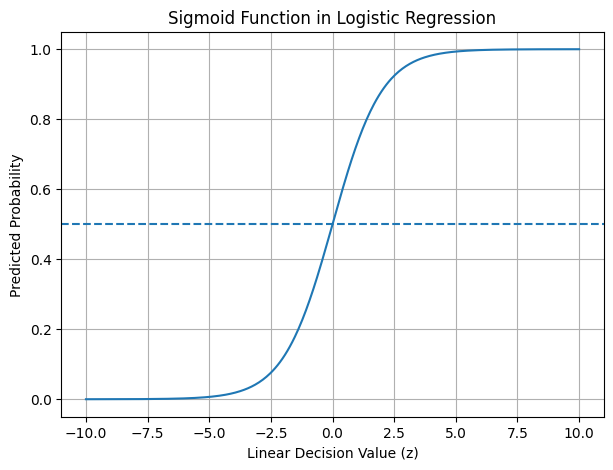

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Linear decision values
z = np.linspace(-10, 10, 400)

# Sigmoid function
sigmoid = 1 / (1 + np.exp(-z))

# Plot
plt.figure(figsize=(7, 5))
plt.plot(z, sigmoid)
plt.axhline(0.5, linestyle='--')
plt.xlabel("Linear Decision Value (z)")
plt.ylabel("Predicted Probability")
plt.title("Sigmoid Function in Logistic Regression")
plt.grid(True)
plt.show()

Figure: Sigmoid function showing the transformation of the linear decision value into a probability in logistic regression.

**Conclusion**

Logistic Regression with Elastic Net regularization is effective for predicting customer churn in the Telco dataset. Cross-validation helps select optimal hyperparameters and improves generalization. Elastic Net manages multicollinearity caused by one-hot encoding and keeps the model stable.

Because the dataset is imbalanced, ROC-AUC is a more appropriate evaluation metric than accuracy. The model learns a linear decision boundary in high-dimensional space and remains interpretable through its coefficients. Overall, this approach balances interpretability, regularization, and predictive performance for churn classification.
